<h1>Task 1: Setting up an API key and .env file (1p)</h1>

In [1]:
from dotenv import load_dotenv
from datetime import date
import os
import requests
import matplotlib.pyplot as plt
import pandas as pd
import json
import seaborn as sns
import sqlite3
import time

In [2]:
# Load all variables from .env into the environment
load_dotenv()
api_key = os.environ.get("MARKETSTACK_API_KEY")

if api_key:
    print(f"Key loaded: {api_key[:5]}...")
else:
    print("ERROR: MARKETSTACK_API_KEY not found. Check your .env file.")

Key loaded: abcaa...


<hr>
<h1>Task 2: Retrieving data from MarketStack (1p)</h1>

In [3]:
#a)
tickers = [
    'META',
    'AAPL',
    'AMZN',
    'NFLX',
    'GOOG',
]

In [4]:
url = f"http://api.marketstack.com/v1/eod?access_key={api_key}&symbols={','.join(tickers)}&date_from=2026-03-01&date_to=2026-03-31&limit=200"
response = requests.get(url)

In [5]:
#b)
data = response.json()
stock = data['data']
df = pd.DataFrame(data=stock)
df.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


In [6]:
#c 
df = df.sort_values(['symbol', 'date'])

#Summary statistics
summary_stats = df.groupby('symbol')['adj_close'].describe()
summary_stats = summary_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(summary_stats.round(4))

#Calculate monthly returns and print the stock with the highest return
monthly = {}
for symbol in df['symbol'].unique():
    open_price = df[df['symbol'] == symbol]['adj_open'].iloc[0]
    close_price = df[df['symbol'] == symbol]['adj_close'].iloc[-1]
    monthly[symbol] = float(((open_price-close_price)/open_price*100).round(2))
    
monthly_df = pd.DataFrame.from_dict(monthly, orient='index', columns=['return_pct']).reset_index()
monthly_df.columns = ['symbol', 'return_pct']
display(monthly_df)

best_ticker = max(monthly, key=monthly.get)
print(f'Highest return: {best_ticker} at {monthly[best_ticker]:.2f}%')




,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.9064,5.5104,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.9950,4.6432,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.9805,10.9286,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.9909,41.3096,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.0764,2.5121,90.92,93.3350,94.795,97.0525,99.17


,symbol,return_pct
0,AAPL,3.28
1,AMZN,-1.82
2,GOOG,5.32
3,META,10.21
4,NFLX,-0.93


Highest return: META at 10.21%


<hr>
<h1>Task 3: Visualizing stock data (1p)</h1>

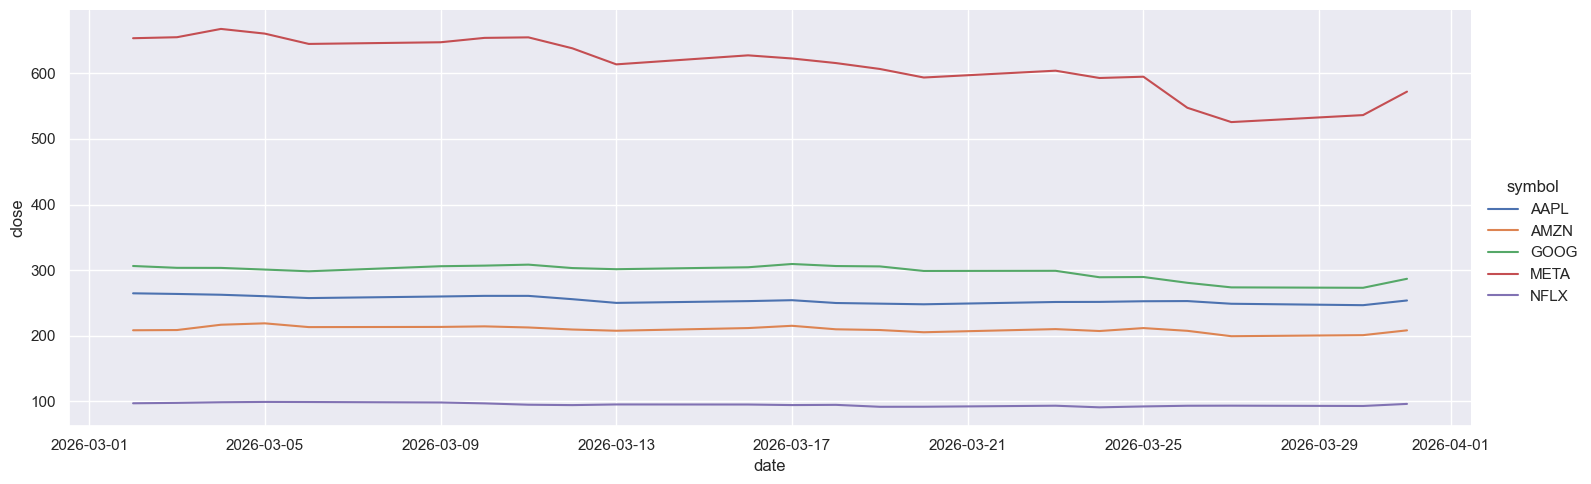

In [7]:
#https://seaborn.pydata.org/tutorial/introduction.html
#a
sns.set_theme()
df['date'] = pd.to_datetime(df['date'], utc=True)
sns.set_theme()
sns.relplot(
    data=df,
    x="date", y="close",
    hue="symbol",
    kind="line",
    height=5,
    aspect=3,
)

[Text(0.5, 0, ''), Text(0, 0.5, 'Return (%)')]

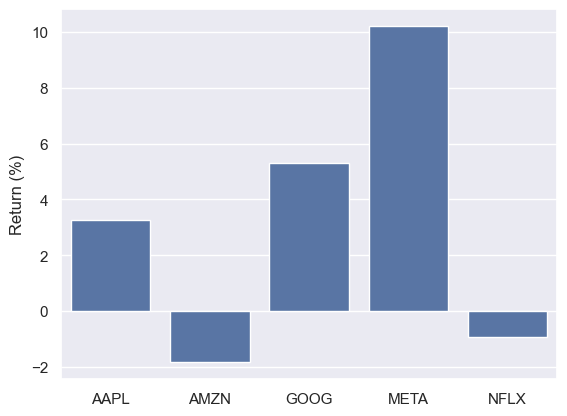

In [8]:
#b
#https://stackoverflow.com/questions/31632637/label-axes-on-seaborn-barplot
monthly_df = pd.DataFrame.from_dict(monthly, orient='index', columns=['return_pct']).reset_index()
monthly_df.columns = ['symbol', 'return_pct']

sns.set_theme()
sns.barplot(
    data=monthly_df,
    x="symbol", y="return_pct",
).set(xlabel='', ylabel='Return (%)')

[Text(0.5, 20.049999999999997, ''), Text(47.25, 0.5, 'Trading volume')]

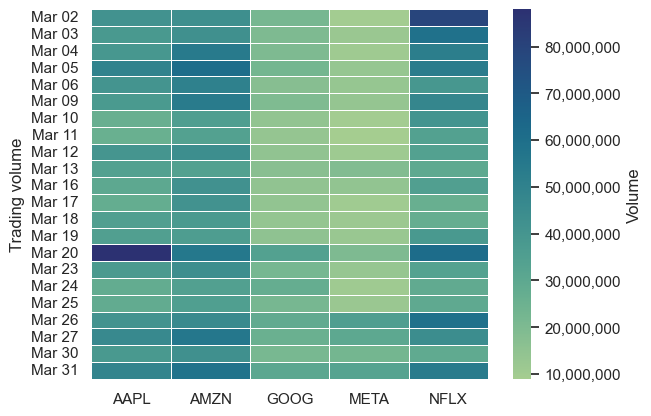

In [9]:
#c
#https://seaborn.pydata.org/generated/seaborn.heatmap.html
df['date_str'] = df['date'].dt.strftime('%b %d')
df_heat = df.pivot(index="date_str", columns="symbol", values="volume")
sns.heatmap(df_heat,
           cmap="crest",
            linewidths=0.5,
            cbar_kws={'label': 'Volume', 'format': '{x:,.0f}'},
).set(xlabel='', ylabel='Trading volume')

<hr>
<h1>Task 4: Exporting and importing data (1p)</h1>

In [10]:
#a
#https://www.youtube.com/watch?v=NarzTiIXrsY
os.makedirs('exports', exist_ok=True)
with open('exports/stockdata.json', 'w') as _f:
    json.dump(data, _f)

#b
df.to_csv('exports/stockdata.csv')

#c
with open("exports/stockdata.json", "r") as jsonfile: 
    from_json = json.load(jsonfile)

from_csv = pd.read_csv('exports/stockdata.csv', index_col=0)
from_csv['date'] = pd.to_datetime(from_csv['date'], utc=True) # fix date as csv doesn't store data type
print(data == from_json)
print(df.equals(from_csv))
display(pd.DataFrame(from_json['data']).head())
display(from_csv.head())

True
True


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date,date_str
105,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02 00:00:00+00:00,Mar 02
100,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03 00:00:00+00:00,Mar 03
95,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04 00:00:00+00:00,Mar 04
90,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05 00:00:00+00:00,Mar 05
85,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06 00:00:00+00:00,Mar 06


<hr>
<h1>Task 5: Querying the Northwind database (1p)</h1>

In [11]:
#https://docs.python.org/3/library/sqlite3.html
#a 
con = sqlite3.connect('northwind-SQLite3-main/dist/northwind.db')
cur = con.cursor()

cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
print(cur.fetchall())

#b
df_products = pd.read_sql("SELECT ProductName, UnitPrice, UnitsInStock FROM Products WHERE UnitPrice > 30", con)
display(df_products.head())

[('Categories',), ('sqlite_sequence',), ('CustomerCustomerDemo',), ('CustomerDemographics',), ('Customers',), ('Employees',), ('EmployeeTerritories',), ('Order Details',), ('Orders',), ('Products',), ('Regions',), ('Shippers',), ('Suppliers',), ('Territories',)]


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.0,6
1,Mishi Kobe Niku,97.0,29
2,Ikura,31.0,31
3,Queso Manchego La Pastora,38.0,86
4,Alice Mutton,39.0,0


In [12]:
#c
query = """
    SELECT c.CompanyName,
           o.OrderID,
           o.OrderDate,
           o.ShipCountry,
           od.UnitPrice * od.Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c ON o.CustomerID = c.CustomerID
    JOIN 'Order Details' od ON o.OrderID = od.OrderID
    WHERE o.ShipCountry = 'Germany'
"""

df_germany = pd.read_sql(query, con)
display(df_germany.head())

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0


<hr>
<h1>Task 6: Visualizing Northwind data (1p)</h1>

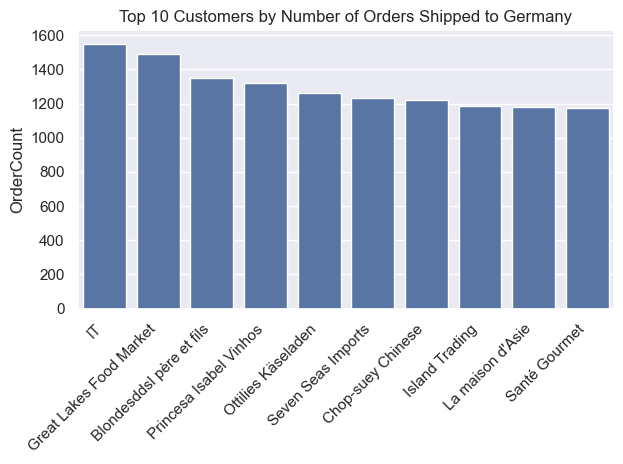

In [13]:
#a
top10 = df_germany.groupby('CompanyName')['OrderID'].count().nlargest(10).reset_index()
top10.columns = ['CompanyName', 'OrderCount']

sns.barplot(
    data=top10,
    x='CompanyName',
    y='OrderCount',
)

plt.title('Top 10 Customers by Number of Orders Shipped to Germany')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

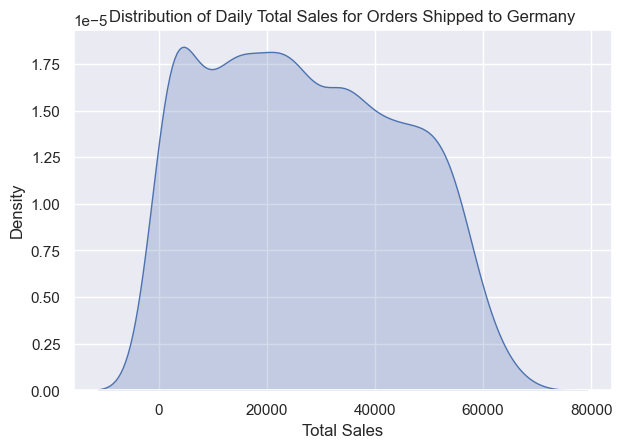

In [14]:
#b
daily_sales = df_germany.groupby('OrderDate')['LineTotal'].sum().reset_index()
daily_sales.columns = ['OrderDate', 'TotalSales']

sns.kdeplot(
    data=daily_sales,
    x='TotalSales',
    fill=True,
)

plt.title('Distribution of Daily Total Sales for Orders Shipped to Germany')
plt.xlabel('Total Sales')
plt.ylabel('Density')
plt.tight_layout()

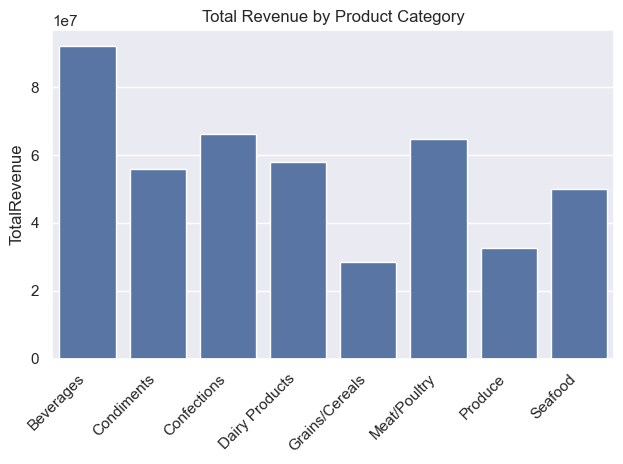

In [15]:
query = """
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
"""

df_revenue = pd.read_sql(query, con)

sns.barplot(
    data=df_revenue,
    x='CategoryName',
    y='TotalRevenue',
)

plt.title('Total Revenue by Product Category')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

<hr>
<h1>Task 7: Comparing Python to SQL (1p)</h1>

In [16]:
#a)
df_products = pd.read_sql("SELECT * FROM Products", con)
df_categories = pd.read_sql("SELECT * FROM Categories", con)

display(df_products.head())
display(df_categories.head())



,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [17]:
#b)
df_joined = pd.merge(df_products, df_categories, on='CategoryID', how='inner')
display(df_joined.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [18]:
# c)

# SQL
start = time.time()
query = """
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
"""
df_sql = pd.read_sql(query, con)
sql_time = time.time() - start

# Pandas
start = time.time()
df_orderdetails = pd.read_sql("SELECT * FROM 'Order Details'", con)
df_products = pd.read_sql("SELECT * FROM Products", con)
df_categories = pd.read_sql("SELECT * FROM Categories", con)

df_pandas = pd.merge(df_orderdetails, df_products, on='ProductID', how='inner')
df_pandas = pd.merge(df_pandas, df_categories, on='CategoryID', how='inner')
df_pandas['TotalRevenue'] = df_pandas['UnitPrice_x'] * df_pandas['Quantity']
df_pandas = df_pandas.groupby('CategoryName')['TotalRevenue'].sum().reset_index()
pandas_time = time.time() - start

print(f'SQL time:    {sql_time:.4f} seconds')
print(f'Pandas time: {pandas_time:.4f} seconds')

SQL time:    0.4869 seconds
Pandas time: 1.4025 seconds


<hr>
<h1>Task 8: Wide and long format (1p)</h1>

In [19]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

In [20]:
#https://pandas.pydata.org/docs/reference/api/pandas.melt.html
#a
print('Before:')
display(wide_data)

melted = pd.melt(wide_data, id_vars='store', var_name='quarter', value_name='sales')

print('After:')
display(melted)

Before:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


After:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [21]:
print("Before:")
display(long_data)

pivoted = long_data.pivot(index="month", columns="product", values="units_sold")

print("After:")
display(pivoted)

Before:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


After:


product,Laptop,Phone
month,,
Feb,50,110
Jan,45,120
Mar,55,130


In [22]:
#c)

# Melted -> back to wide
restored_wide = melted.pivot(index="store", columns="quarter", values="sales").reset_index()
restored_wide.columns.name = None  # remove the "quarter" label from columns

print("Restored wide:")
display(restored_wide)

# Pivoted -> back to long
restored_long = pivoted.reset_index().melt(id_vars="month", var_name="product", value_name="units_sold")
restored_long = restored_long.sort_values("month").reset_index(drop=True)

print("Restored long:")
display(restored_long)

Restored wide:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Restored long:


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130
